In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Carregar o dataset gerado pelo teu script de download
caminho = '../data/dataset.csv'

if os.path.exists(caminho):
    df = pd.read_csv(caminho).dropna()
    print(f"✅ Dataset carregado com sucesso! Total de textos: {len(df)}")
    print(f"Classes presentes: {df['label'].unique()}")
else:
    print("⚠️ ERRO: O dataset.csv não foi encontrado.")
    
df.head()

✅ Dataset carregado com sucesso! Total de textos: 3455
Classes presentes: ['google' 'human' 'mistral' 'meta' 'openai']


,text,label
0,Goodell Doubles Down on Anthem Stance: NFL Wan...,google
1,Why I'm Using Cookies To Help Sell My First Bo...,google
2,it saves them effort . reddit gets a huge amou...,human
3,Alec Baldwin to Revive Trump Impression for SN...,mistral
4,Getting Married in the Philippines: A Celebrat...,google


Distribuição das classes:
label
google     691
human      691
mistral    691
meta       691
openai     691
Name: count, dtype: int64


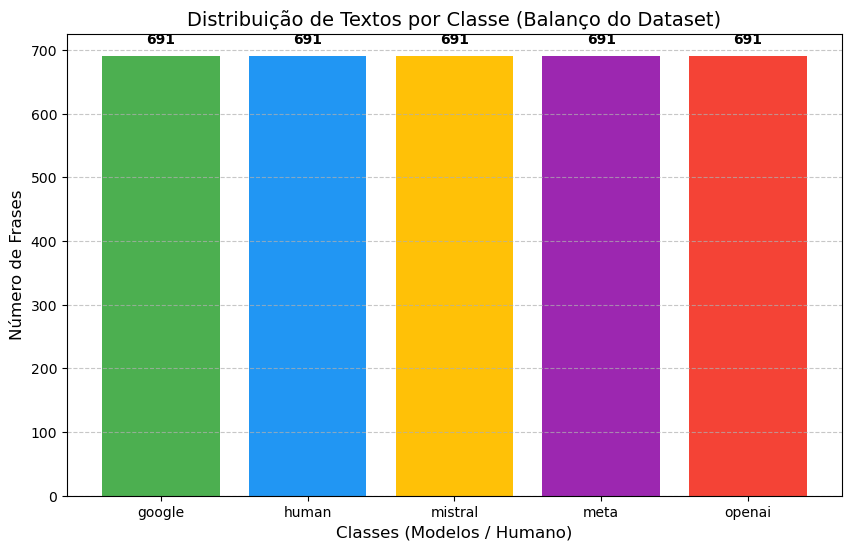

In [2]:
# Contar quantos textos temos de cada classe
contagem_classes = df['label'].value_counts()
print("Distribuição das classes:")
print(contagem_classes)

# Criar um gráfico de barras profissional
plt.figure(figsize=(10, 6))

# Lista de cores para as nossas 5 classes (Humano + 4 IAs)
cores = ['#4CAF50', '#2196F3', '#FFC107', '#9C27B0', '#F44336']
bars = plt.bar(contagem_classes.index, contagem_classes.values, color=cores[:len(contagem_classes)])

# Adicionar o número exato em cima de cada barra
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (yval*0.02), int(yval), 
             ha='center', va='bottom', fontweight='bold')

plt.title('Distribuição de Textos por Classe (Balanço do Dataset)', fontsize=14)
plt.xlabel('Classes (Modelos / Humano)', fontsize=12)
plt.ylabel('Número de Frases', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

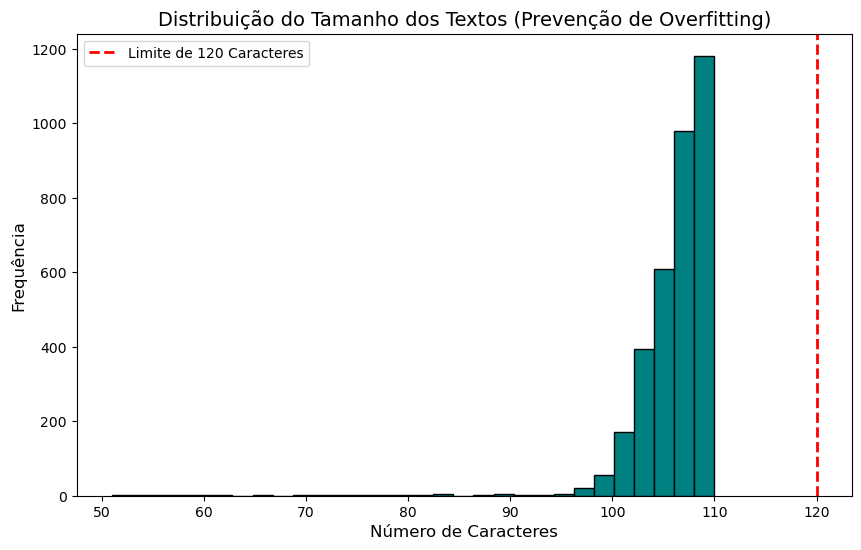

Tamanho médio dos textos: 106.6 caracteres
Tamanho máximo: 110 caracteres
Tamanho mínimo: 51 caracteres


In [3]:
# Calcular o tamanho de cada texto
df['tamanho_texto'] = df['text'].apply(lambda x: len(str(x)))

# Fazer um Histograma para mostrar a distribuição dos tamanhos
plt.figure(figsize=(10, 6))
plt.hist(df['tamanho_texto'], bins=30, color='teal', edgecolor='black')

# Adicionar a linha vermelha a marcar o limite (ex: 120 caracteres)
plt.axvline(x=120, color='red', linestyle='dashed', linewidth=2, label='Limite de 120 Caracteres')

plt.title('Distribuição do Tamanho dos Textos (Prevenção de Overfitting)', fontsize=14)
plt.xlabel('Número de Caracteres', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.legend()
plt.show()

# Imprimir as estatísticas finais
print(f"Tamanho médio dos textos: {df['tamanho_texto'].mean():.1f} caracteres")
print(f"Tamanho máximo: {df['tamanho_texto'].max()} caracteres")
print(f"Tamanho mínimo: {df['tamanho_texto'].min()} caracteres")

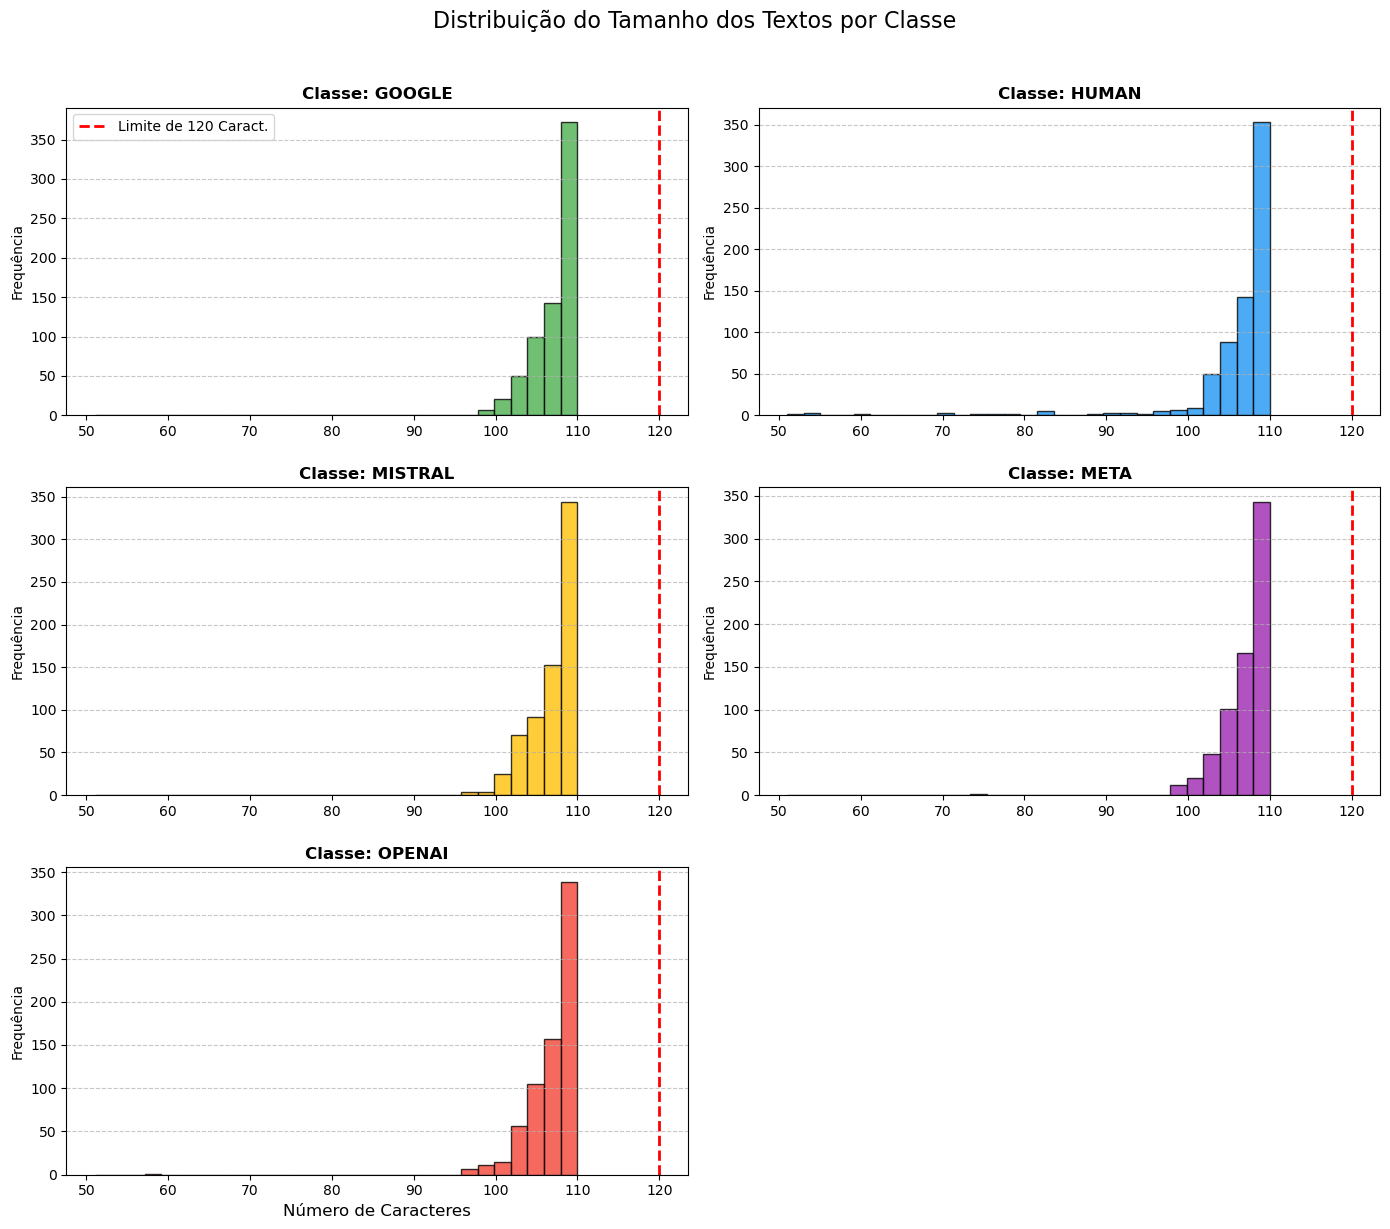

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import math

# Calcular o tamanho de cada texto
df['tamanho_texto'] = df['text'].apply(lambda x: len(str(x)))

cores = ['#4CAF50', '#2196F3', '#FFC107', '#9C27B0', '#F44336']
classes = df['label'].unique()
num_classes = len(classes)

colunas = 2
linhas = math.ceil(num_classes / colunas)

# Mantemos o sharex=True para garantir que a escala é perfeitamente igual em todos
fig, axes = plt.subplots(linhas, colunas, figsize=(14, 4 * linhas), sharex=True)
axes = axes.flatten()

fig.suptitle('Distribuição do Tamanho dos Textos por Classe', fontsize=16, y=1.02)

# Os nossos "baldes" globais para as barras terem a mesma largura
bins_globais = np.linspace(df['tamanho_texto'].min(), df['tamanho_texto'].max(), 30)

for i, classe in enumerate(classes):
    subset = df[df['label'] == classe]
    ax = axes[i]
    
    ax.hist(subset['tamanho_texto'], bins=bins_globais, alpha=0.8, 
            color=cores[i % len(cores)], edgecolor='black')
    
    ax.axvline(x=120, color='red', linestyle='dashed', linewidth=2, label='Limite de 120 Caract.')
    
    ax.set_title(f'Classe: {classe.upper()}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Frequência', fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    # ---> A CORREÇÃO ESTÁ AQUI <---
    # Forçar a exibição dos números no eixo X, mesmo com o sharex=True
    ax.tick_params(labelbottom=True)
    
    if i == 0:
        ax.legend()

for j in range(num_classes, len(axes)):
    fig.delaxes(axes[j])

for ax in axes[-colunas:]:
    ax.set_xlabel('Número de Caracteres', fontsize=12)

# Ajustar os espaços adicionando h_pad para garantir que os números não batem nos títulos de baixo
plt.tight_layout(h_pad=2.0)
plt.show()